In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns

In [6]:
#use elbow method to find the number of clusters the more wcss as number of clusters increases.

In [7]:
#kmeans++ as random initialisation of clusters centers

In [8]:
dataset  = pd.read_csv('Country-data.csv')

In [9]:
dataset.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [10]:
dataset.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [11]:
"""Objective:
To categorise the countries using socio-economic and health factors that determine the overall development of the country.

About organization:
HELP International is an international humanitarian NGO that is committed to fighting poverty and providing the people of backward countries with basic amenities and
 relief during the time of disasters and natural calamities.

Problem Statement:
HELP International have been able to raise around $ 10 million. Now the CEO of the NGO needs to decide how to use this money strategically and effectively. So, CEO has
to make decision to choose the countries that are in the direst need of aid. Hence, your Job as a Data scientist is to categorise the countries using some socio-economic
and health factors that determine the overall development of the country. Then you need to suggest the countries which the CEO needs to focus on the most."""

'Objective:\nTo categorise the countries using socio-economic and health factors that determine the overall development of the country.\n\nAbout organization:\nHELP International is an international humanitarian NGO that is committed to fighting poverty and providing the people of backward countries with basic amenities and\n relief during the time of disasters and natural calamities.\n\nProblem Statement:\nHELP International have been able to raise around $ 10 million. Now the CEO of the NGO needs to decide how to use this money strategically and effectively. So, CEO has\nto make decision to choose the countries that are in the direst need of aid. Hence, your Job as a Data scientist is to categorise the countries using some socio-economic\nand health factors that determine the overall development of the country. Then you need to suggest the countries which the CEO needs to focus on the most.'

In [12]:
df = dataset.drop("country",axis=1)

In [13]:
df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [14]:
df.isna().sum()

child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

<Axes: xlabel='child_mort', ylabel='Count'>

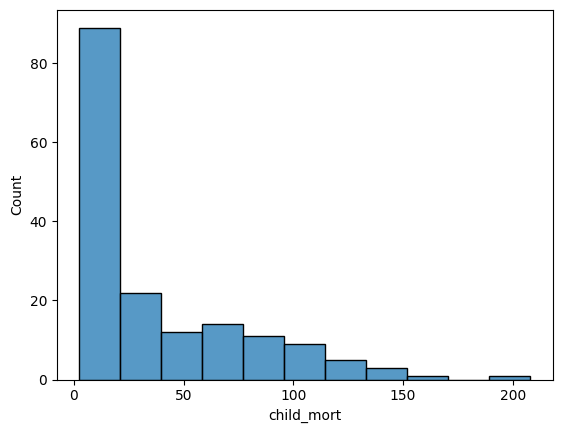

In [15]:
sns.histplot(dataset,x='child_mort')

<Axes: xlabel='exports', ylabel='Count'>

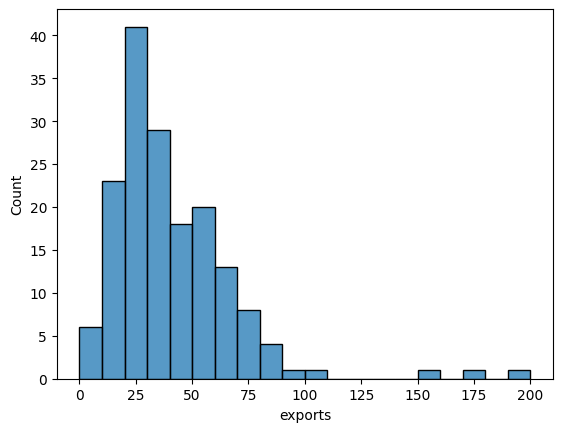

In [16]:
sns.histplot(dataset,x='exports')

<Axes: xlabel='child_mort', ylabel='exports'>

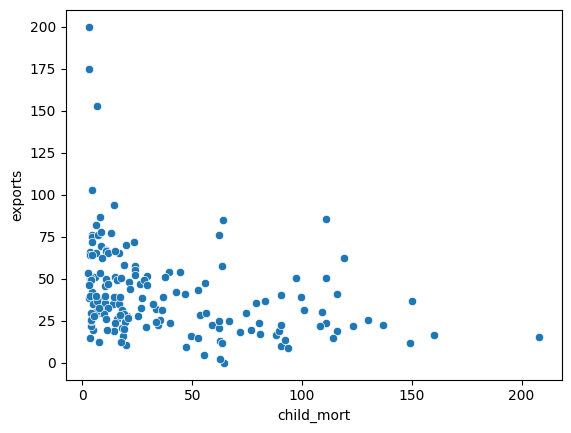

In [17]:
sns.scatterplot(df,x='child_mort',y='exports')

<Axes: xlabel='child_mort', ylabel='health'>

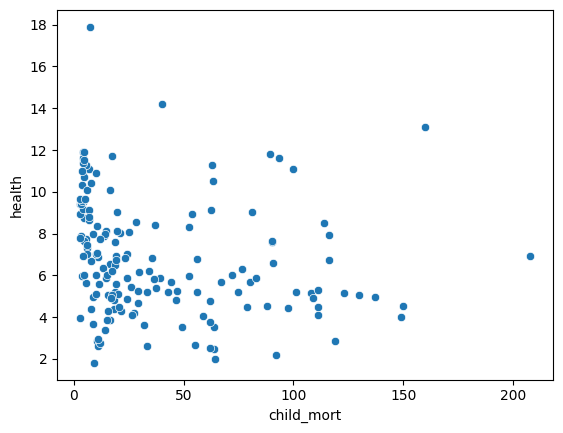

In [18]:
sns.scatterplot(df,x='child_mort',y='health')

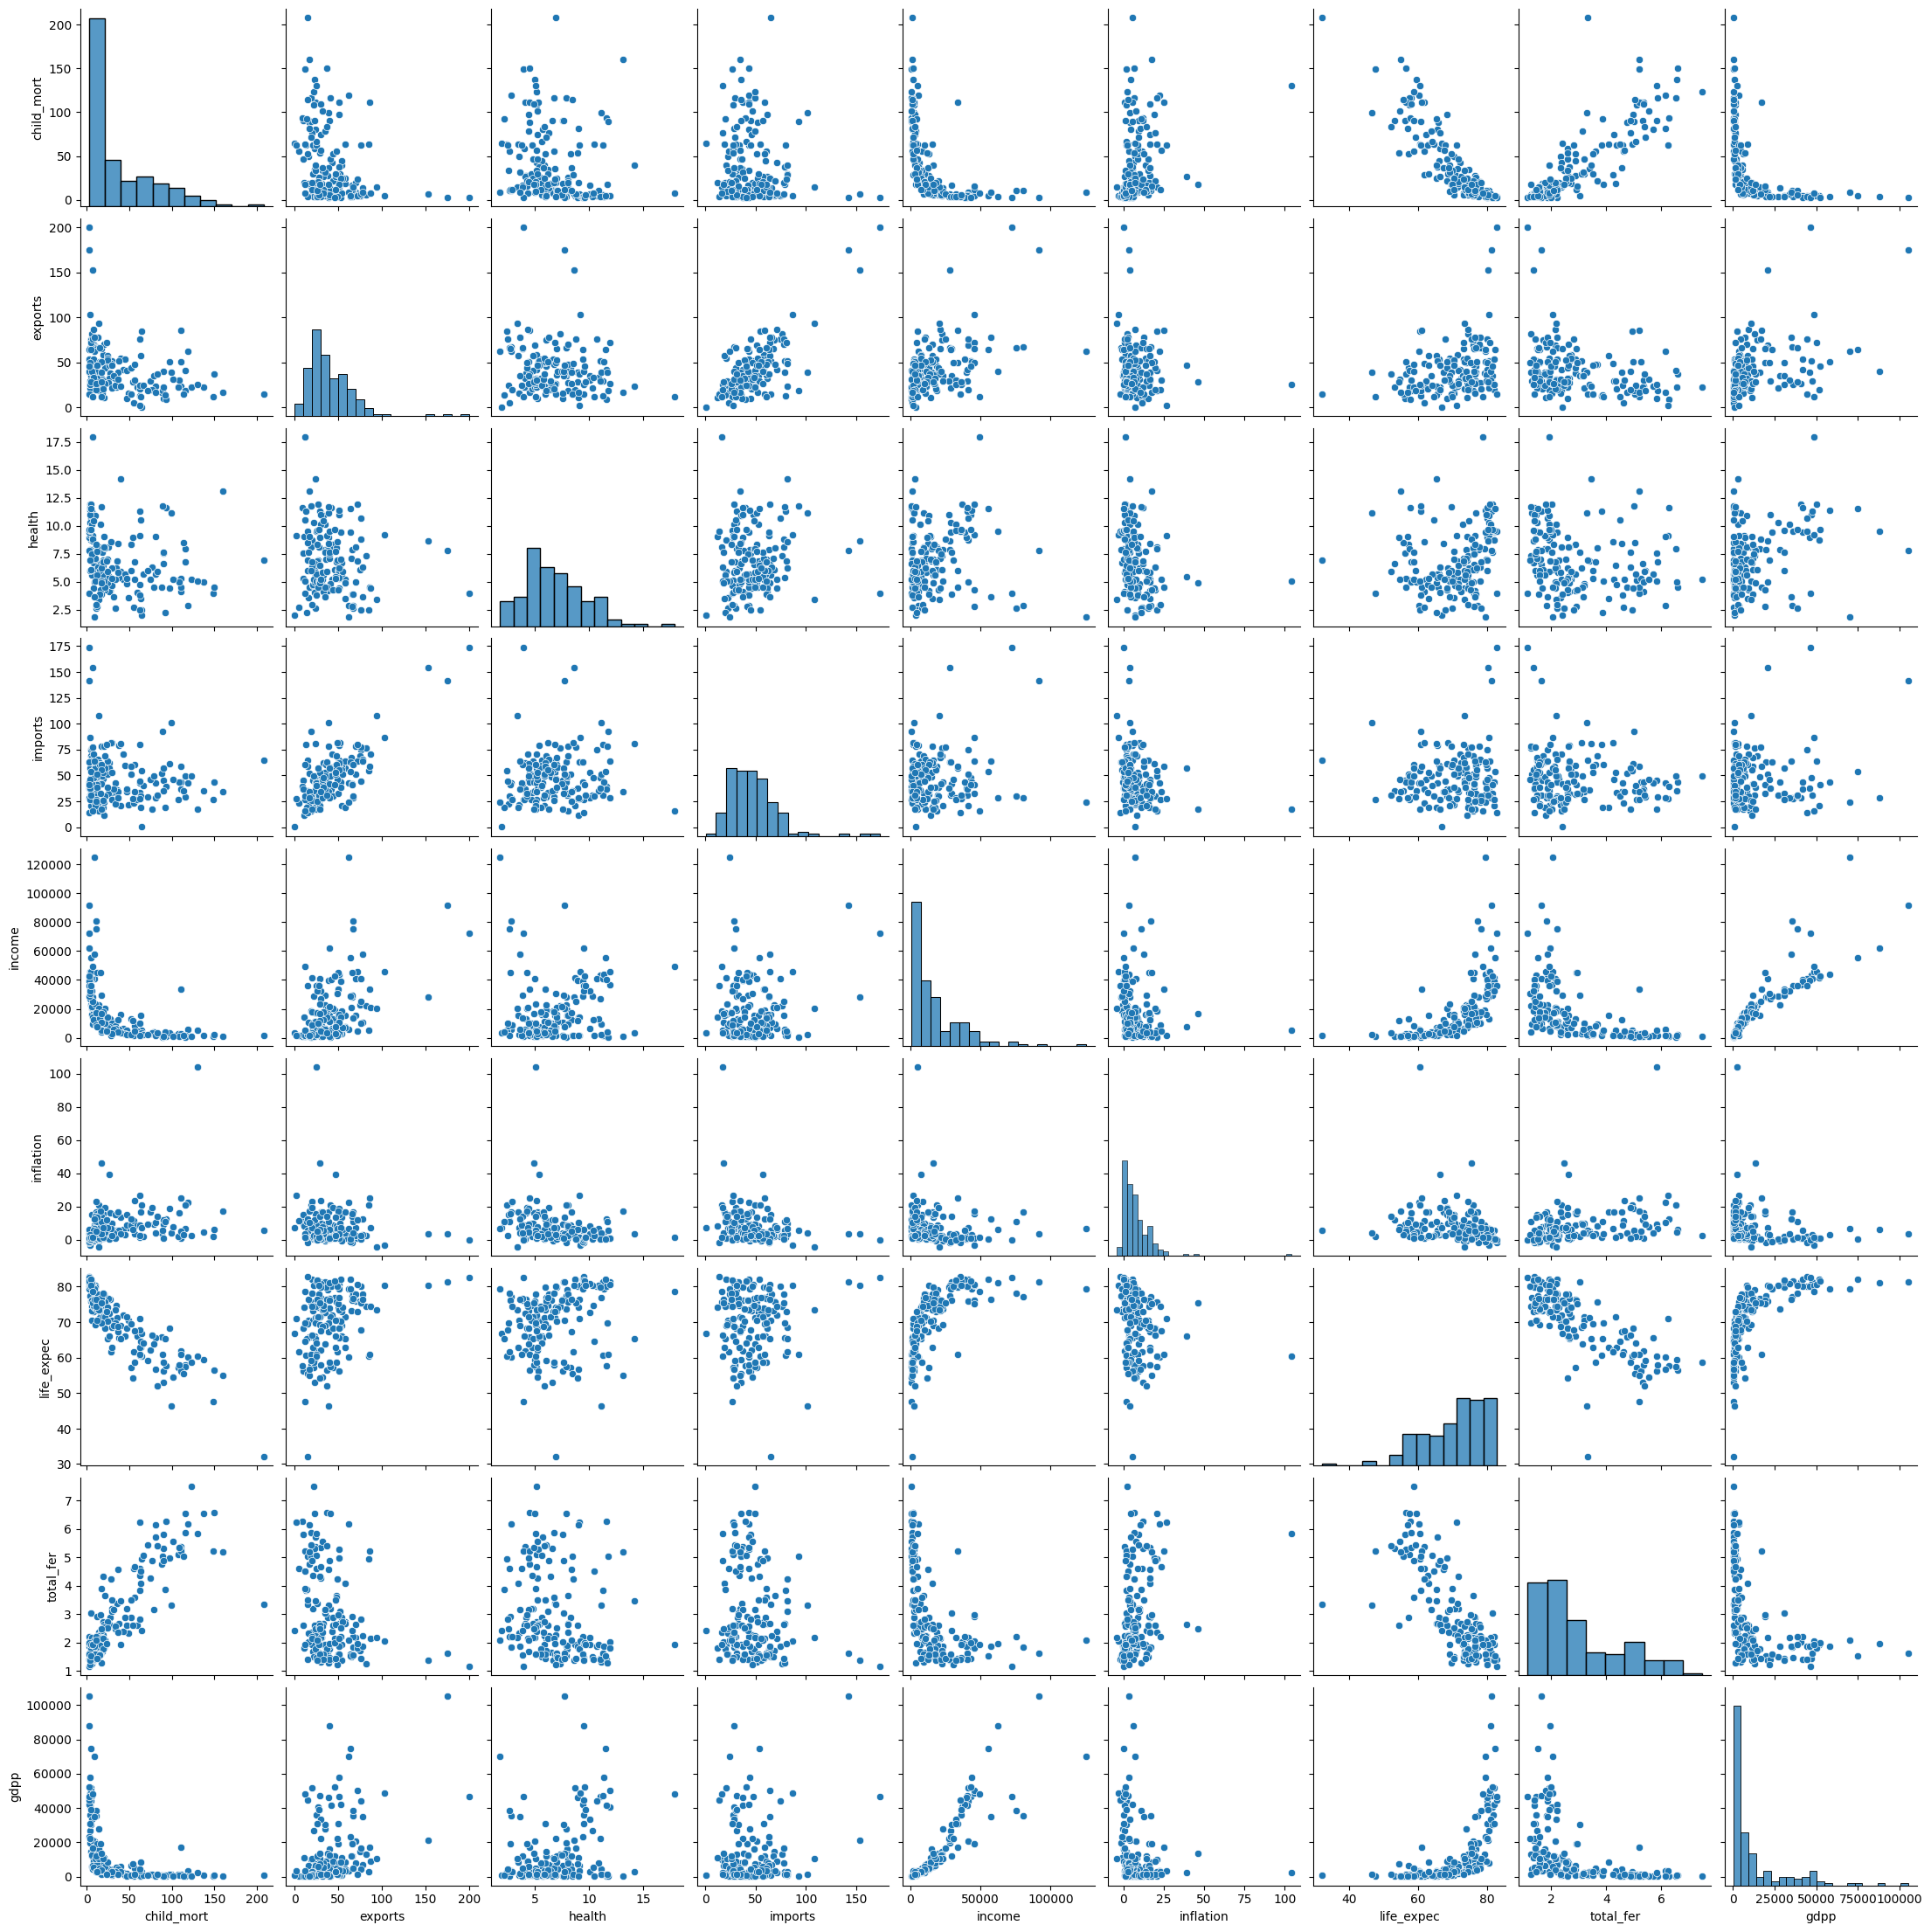

In [19]:
sns.pairplot(df)

In [20]:
total_wcss = []
for i in range(1,11):
    wcss=0
    k = KMeans(n_clusters=i,init='k-means++',random_state=42)
    k.fit(df)
    wcss = k.inertia_
    total_wcss.append(wcss)


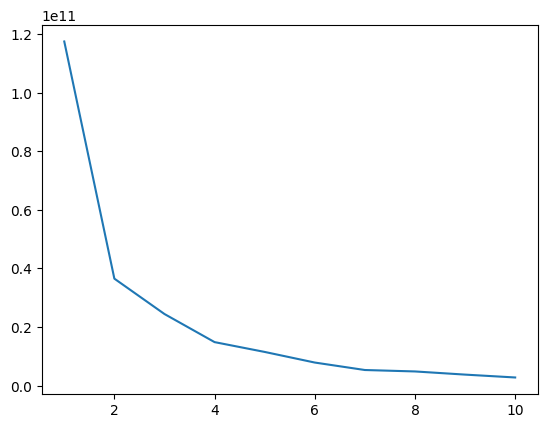

In [21]:
plt.plot(np.arange(1,11),total_wcss)

In [22]:
num_clusters = 4

In [23]:
kmeans = KMeans(n_clusters=num_clusters,init='k-means++',random_state=42)

In [24]:
kmeans.fit(df)

KMeans(n_clusters=4, random_state=42)

In [25]:
kmeans.inertia_

14874385989.227547

In [26]:
kmeans.get_feature_names_out()

array(['kmeans0', 'kmeans1', 'kmeans2', 'kmeans3'], dtype=object)

In [27]:
predictions =kmeans.predict(df)
print(predictions)

[0 0 0 0 2 2 0 1 1 0 2 2 0 2 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 2 0 0 0
 0 0 0 0 2 2 2 1 0 0 0 0 2 0 2 0 1 1 0 0 0 1 0 2 0 0 0 0 0 0 2 1 0 0 0 0 1
 2 1 0 1 0 2 0 0 1 0 0 2 0 0 0 2 2 3 0 0 0 2 0 0 2 0 0 0 0 0 0 0 0 0 0 0 1
 2 0 0 3 2 0 0 0 0 0 2 2 3 2 2 0 0 2 0 0 2 0 1 2 2 0 0 2 2 0 0 0 0 1 3 0 0
 0 0 0 0 0 2 0 0 0 1 1 1 2 0 0 2 0 0 0]


<Axes: xlabel='child_mort', ylabel='exports'>

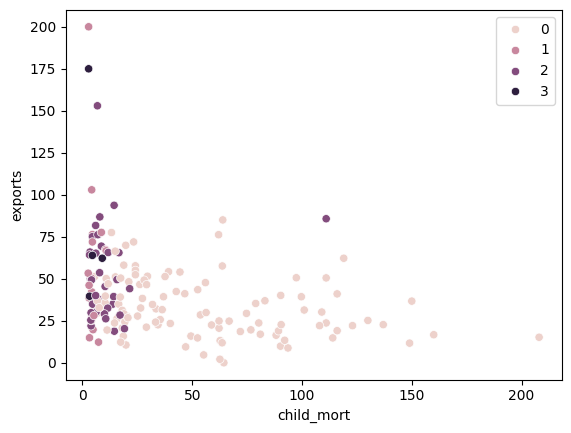

In [28]:
sns.scatterplot(df,x='child_mort',y='exports',hue=predictions)


In [29]:
df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<Axes: xlabel='gdpp', ylabel='total_fer'>

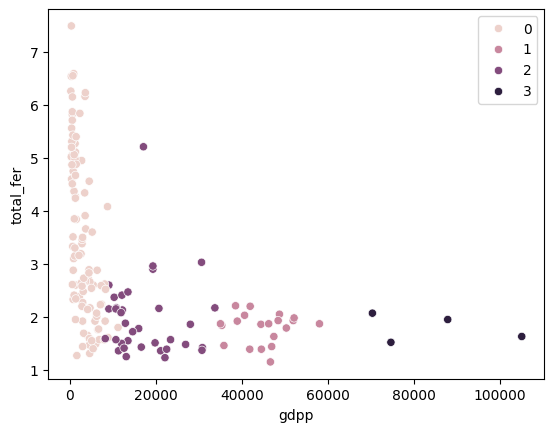

In [30]:
sns.scatterplot(df,x='gdpp',y='total_fer',hue=predictions)


<Axes: xlabel='gdpp', ylabel='income'>

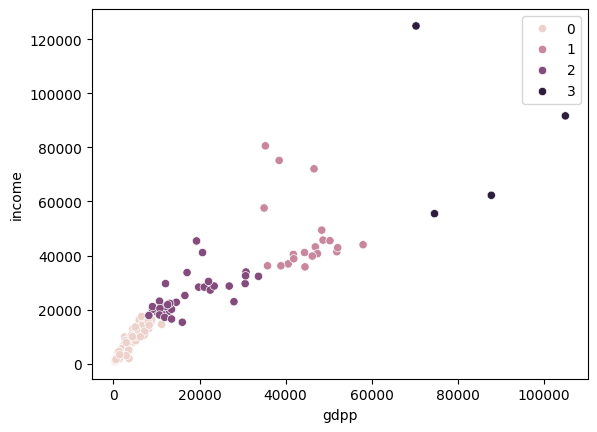

In [31]:
sns.scatterplot(df,x='gdpp',y='income',hue=predictions)

In [32]:
from kneed import KneeLocator

In [33]:
kl = KneeLocator(np.arange(1,11),total_wcss,curve="convex",direction="decreasing")

In [34]:
kl.elbow

np.int64(2)

In [35]:
from sklearn.metrics import silhouette_score
sil_coefficients=[]
for i in range(2,11):
    wcss=0
    k = KMeans(n_clusters=i,init='k-means++',random_state=42)
    k.fit(df)
    score = silhouette_score(df,k.labels_)
    sil_coefficients.append(score)

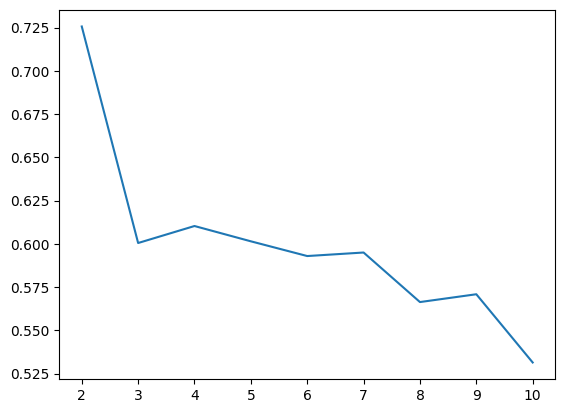

In [36]:
plt.plot(np.arange(2,11),sil_coefficients)

In [37]:
#we can use stardard scaler, pca also